In [1]:
import pandas as pd

path = r"C:\Users\chris\repositories\deep-learning-with-python-notebooks\layering_examples_ch_7\insurance.csv"
df = pd.read_csv(path)

In [2]:
print(df.shape)
print(df.head())
print(df.isnull().sum().sort_values(ascending=False))

(1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [3]:
# import matplotlib.pyplot as plt

# # assuming you still have the original dataframe
# df.boxplot(column='charges', by='smoker')
# plt.show()

In [4]:
df["sex"] = df["sex"].map({"male": 1, "female": 0})

df["smoker"] = df["smoker"].map({"yes": 1, "no": 0})

In [5]:
df = pd.get_dummies(df, columns=["region"], dtype=int)
df = df.drop(columns=['region_southwest'])

In [6]:
print(df.head())

   age  sex     bmi  children  smoker      charges  region_northeast  \
0   19    0  27.900         0       1  16884.92400                 0   
1   18    1  33.770         1       0   1725.55230                 0   
2   28    1  33.000         3       0   4449.46200                 0   
3   33    1  22.705         0       0  21984.47061                 0   
4   32    1  28.880         0       0   3866.85520                 0   

   region_northwest  region_southeast  
0                 0                 0  
1                 0                 1  
2                 0                 1  
3                 1                 0  
4                 1                 0  


In [7]:
df.dtypes

age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
region_northeast      int64
region_northwest      int64
region_southeast      int64
dtype: object

In [8]:
df

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast
0,19,0,27.900,0,1,16884.92400,0,0,0
1,18,1,33.770,1,0,1725.55230,0,0,1
2,28,1,33.000,3,0,4449.46200,0,0,1
3,33,1,22.705,0,0,21984.47061,0,1,0
4,32,1,28.880,0,0,3866.85520,0,1,0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,0,1,0
1334,18,0,31.920,0,0,2205.98080,1,0,0
1335,18,0,36.850,0,0,1629.83350,0,0,1
1336,21,0,25.800,0,0,2007.94500,0,0,0


In [9]:
X = df.drop('charges', axis=1).values  # convention to use uppercase X for matrix
y = df['charges'].values     #convert to NumPy array, which Keras expects           

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  # 80% train, 20% test, fixed seed for reproducibility
)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#scaler.fit(X_train)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train.reshape(-1,1)).flatten()
y_test = y_scaler.transform(y_test.reshape(-1,1)).flatten()



In [12]:
X.shape

(1338, 8)

In [13]:
import os
os.environ["KERAS_BACKEND"] = "jax"

from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

In [14]:
import keras
from keras import layers

In [15]:
# inputs = keras.Input(shape=(32,), name="my_input")
# feature1 = layers.Dense(64, activation='relu')(inputs)
# feature2 = layers.Dense(32, activation='relu')(feature1)
# outputs = layers.Dense(1)(feature2)
# model = keras.Model(inputs = inputs, outputs = outputs, name="my_functional_model")


In [16]:
inputs = keras.Input(shape=(8,), name="my_input")

feature1 = layers.Dense(64, activation='relu')(inputs)
feature2 = layers.Dense(64, activation='relu')(feature1)
feature3 = layers.Dense(64, activation='relu')(feature2)
outputs = layers.Dense(1)(feature3)

model = keras.Model(inputs = inputs, outputs = outputs, name="my_functional_model")

In [17]:
model.compile(
    optimizer='adam',          # good default for most tasks
    loss='mse',               # squared error penalises large errors more
    metrics=['mae']           # average absolute error, easier to interpret
)

In [18]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=10,
    restore_best_weights=True,
)

history = model.fit(
    x=X_train,
    y=y_train,
    batch_size=None,
    epochs=500,
    verbose="auto",
    callbacks=[early_stop],
    validation_split=0.2,
    validation_data=None,
    shuffle=True,
    #class_weight=None,
    #sample_weight=None,
    #initial_epoch=0,
)


Epoch 1/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.6495 - mae: 0.5961 - val_loss: 0.3149 - val_mae: 0.4115
Epoch 2/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2342 - mae: 0.3264 - val_loss: 0.1761 - val_mae: 0.2799
Epoch 3/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step - loss: 0.1849 - mae: 0.2789 - val_loss: 0.1658 - val_mae: 0.2486
Epoch 4/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step - loss: 0.1713 - mae: 0.2485 - val_loss: 0.1560 - val_mae: 0.2757
Epoch 5/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step - loss: 0.1665 - mae: 0.2670 - val_loss: 0.1516 - val_mae: 0.2269
Epoch 6/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step - loss: 0.1548 - mae: 0.2398 - val_loss: 0.1559 - val_mae: 0.2510
Epoch 7/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step - loss: 0.1522 - mae: 0.2470 - val_loss: 0.1508 - val_mae: 0.2148
Epoch 8/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step - loss: 0.1475 - mae: 0.2284 - val_loss: 0.1683 - val_mae: 0.2411
Epoch 9/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/ste

In [19]:
print(history.history['val_loss'][-10:])
print(history.history['mae'][-1])       # final training MAE
   # final validation MAE

[0.1761220544576645, 0.16582126915454865, 0.15597134828567505, 0.15158724784851074, 0.15591564774513245, 0.1508241444826126, 0.16834217309951782, 0.15124918520450592, 0.14461475610733032, 0.14856821298599243]
0.23611034452915192


In [20]:
print(history.history['val_mae'][-1])

0.24870017170906067


In [ ]:
# inverse-transform to get back to dollar scale
val_mae_dollars = history.history['val_mae'][-1] * y_scaler.scale_[0] # scale_ holds the std deviation

print(f"Validation MAE: ${val_mae_dollars:.2f}")

Validation MAE: $4980.96


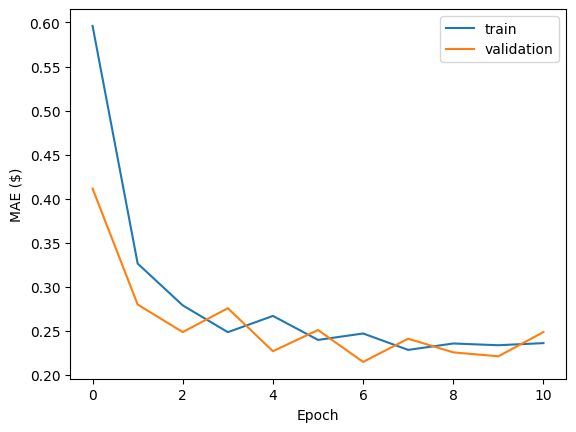

In [22]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('MAE ($)')
plt.legend()
plt.show()

In [25]:
predictions = model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [26]:
from sklearn.metrics import mean_absolute_error

actuals = y_scaler.inverse_transform(y_test.reshape(-1, 1))
predictions_dollars = y_scaler.inverse_transform(predictions)

mae_dollars = mean_absolute_error(actuals, predictions_dollars)
print(f"MAE: ${mae_dollars:,.2f}")

MAE: $5,148.57


In [27]:
import numpy as np

actuals = y_scaler.inverse_transform(y_test.reshape(-1, 1))  # back to dollars

for i in range(5):
    print(f"Predicted: ${predictions_dollars[i][0]:,.2f}  |  Actual: ${actuals[i][0]:,.2f}")

Predicted: $10,364.30  |  Actual: $9,095.07
Predicted: $9,979.83  |  Actual: $5,272.18
Predicted: $29,719.68  |  Actual: $29,330.98
Predicted: $11,416.89  |  Actual: $9,301.89
Predicted: $24,206.42  |  Actual: $33,750.29
